# Proyecto Final - Analítica de Negocios
## Predicción de demanda y segmentación de tiendas en retail

**Dataset seleccionado:** Walmart Sales Dataset  
**Variable numérica de pronóstico:** `Weekly_Sales`  
**Variables categóricas / de agrupamiento:** `Store` y `Holiday_Flag`  
**Modelos utilizados:** Random Forest Regressor y K-Means Clustering  

---

## 1. Introducción

En el sector retail, la toma de decisiones depende cada vez más de la capacidad de convertir los datos históricos en información útil para la planeación. Las empresas que administran varias tiendas necesitan anticipar la demanda, organizar inventarios, planear personal, definir promociones, gestionar transporte y tomar decisiones de abastecimiento. Cuando una organización no logra estimar adecuadamente sus ventas, puede enfrentar exceso de inventario, falta de productos, pérdidas por descuentos innecesarios o una mala experiencia para el cliente.

Este proyecto utiliza un dataset de ventas semanales de Walmart para aplicar técnicas de analítica de negocios. La base de datos contiene información por tienda y semana, incluyendo ventas semanales, fecha, semanas festivas, temperatura, precio del combustible, índice de precios al consumidor y desempleo. A partir de estas variables se busca construir un análisis que permita comprender los factores asociados al comportamiento de las ventas y segmentar registros con características similares.

El trabajo se enfoca en dos tipos de análisis. Primero, se desarrolla un modelo de pronóstico para estimar la variable `Weekly_Sales`, que representa las ventas semanales. Segundo, se aplica un modelo de agrupamiento mediante K-Means para identificar patrones entre semanas o tiendas con comportamientos similares. Estos dos enfoques permiten apoyar decisiones gerenciales relacionadas con inventario, logística, precios, promociones y planeación comercial.

## 2. Definición del problema

Las cadenas de retail enfrentan variaciones constantes en la demanda. Las ventas pueden cambiar por factores internos, como el desempeño de cada tienda, y por factores externos, como la temporada, las semanas festivas, el comportamiento económico, la inflación, el desempleo o los costos asociados al combustible. Para una empresa como Walmart, anticipar estas variaciones es fundamental porque permite planear recursos con mayor precisión.

El problema de negocio se formula de la siguiente manera:

**¿Cómo puede una organización de retail predecir sus ventas semanales y segmentar sus tiendas o semanas de venta para mejorar la toma de decisiones operativas y comerciales?**

### Objetivo general

Construir un portafolio de análisis que permita predecir las ventas semanales y agrupar registros con características similares usando técnicas de analítica de negocios.

### Objetivos específicos

1. Describir la base de datos y clasificar sus variables según su posible uso analítico.
2. Preparar los datos mediante limpieza, transformación de fechas y creación de variables temporales.
3. Realizar un análisis exploratorio para identificar patrones en ventas, semanas festivas y variables económicas.
4. Construir un modelo de pronóstico para estimar `Weekly_Sales`.
5. Aplicar un modelo de agrupamiento para segmentar registros con comportamiento similar.
6. Interpretar los resultados desde una perspectiva de negocio.
7. Proponer recomendaciones para apoyar decisiones de inventario, promociones y planeación.

## 3. Recopilar y preparar datos

En esta sección se cargan las librerías, se importa el dataset y se revisa su estructura. El archivo debe estar disponible en Google Colab con el nombre `Walmart_Sales.csv`. Si el archivo se encuentra en Google Drive, se puede montar Drive y cambiar la ruta.

In [1]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score

# Configuración visual
sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Para reproducibilidad
RANDOM_STATE = 42

In [5]:

# Carga del dataset
df = pd.read_csv("/content/drive/MyDrive/Walmart_Sales.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,"1,643,690.90",0,42.31,2.57,211.10,8.11
1,1,12-02-2010,"1,641,957.44",1,38.51,2.55,211.24,8.11
2,1,19-02-2010,"1,611,968.17",0,39.93,2.51,211.29,8.11
3,1,26-02-2010,"1,409,727.59",0,46.63,2.56,211.32,8.11
4,1,05-03-2010,"1,554,806.68",0,46.50,2.62,211.35,8.11


In [6]:
# Tamaño del dataset y tipos de datos
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print("\nInformación general:")
df.info()

Filas: 6435
Columnas: 8

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [7]:
# Revisión de valores nulos
nulos = df.isnull().sum().sort_values(ascending=False)
print("Valores nulos por variable:")
print(nulos)

Valores nulos por variable:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [8]:
# Resumen estadístico de variables numéricas
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,"6,435.00","6,435.00","6,435.00","6,435.00","6,435.00","6,435.00","6,435.00"
mean,23.00,"1,046,964.88",0.07,60.66,3.36,171.58,8.00
std,12.99,"564,366.62",0.26,18.44,0.46,39.36,1.88
min,1.00,"209,986.25",0.00,-2.06,2.47,126.06,3.88
25%,12.00,"553,350.10",0.00,47.46,2.93,131.74,6.89
50%,23.00,"960,746.04",0.00,62.67,3.44,182.62,7.87
75%,34.00,"1,420,158.66",0.00,74.94,3.73,212.74,8.62
max,45.00,"3,818,686.45",1.00,100.14,4.47,227.23,14.31


### 3.1 Preparación de variables

La variable `Date` se convierte a formato fecha para crear variables temporales. Estas variables permiten capturar patrones de año, mes y semana. Además, se valida que `Holiday_Flag` sea numérica, ya que representa si la semana corresponde o no a una festividad.

In [9]:
# Conversión de fecha
# En muchos archivos de este dataset la fecha viene en formato día/mes/año.
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Eliminar registros con fecha no interpretable, si existieran
df = df.dropna(subset=['Date']).copy()

# Creación de variables temporales
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

# Asegurar formato entero de Holiday_Flag
df['Holiday_Flag'] = df['Holiday_Flag'].astype(int)

# Validación final
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week
0,1,2010-02-05,"1,643,690.90",0,42.31,2.57,211.10,8.11,2010,2,5
1,1,2010-02-12,"1,641,957.44",1,38.51,2.55,211.24,8.11,2010,2,6
2,1,2010-02-19,"1,611,968.17",0,39.93,2.51,211.29,8.11,2010,2,7
3,1,2010-02-26,"1,409,727.59",0,46.63,2.56,211.32,8.11,2010,2,8
4,1,2010-03-05,"1,554,806.68",0,46.50,2.62,211.35,8.11,2010,3,9


In [10]:
# Verificación final de nulos después de la preparación
print(df.isnull().sum())

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Year            0
Month           0
Week            0
dtype: int64


## 4. Descripción de la base de datos y de las variables

El dataset contiene información histórica de ventas semanales de tiendas Walmart. Cada fila representa una observación semanal asociada a una tienda.

| Variable | Tipo | Descripción | Uso en el proyecto |
|---|---|---|---|
| `Store` | Categórica / numérica discreta | Identificador de la tienda | Variable de agrupamiento y explicativa |
| `Date` | Fecha | Fecha o semana del registro | Base para crear variables temporales |
| `Weekly_Sales` | Numérica continua | Ventas semanales de la tienda | Variable objetivo de pronóstico |
| `Holiday_Flag` | Categórica binaria | Indica si la semana fue festiva: 1 sí, 0 no | Variable explicativa y de segmentación |
| `Temperature` | Numérica continua | Temperatura promedio de la semana | Variable explicativa |
| `Fuel_Price` | Numérica continua | Precio del combustible | Variable explicativa |
| `CPI` | Numérica continua | Índice de precios al consumidor | Variable explicativa |
| `Unemployment` | Numérica continua | Tasa de desempleo | Variable explicativa |
| `Year` | Numérica discreta | Año extraído de la fecha | Variable explicativa temporal |
| `Month` | Numérica discreta | Mes extraído de la fecha | Variable explicativa temporal |
| `Week` | Numérica discreta | Semana del año extraída de la fecha | Variable explicativa temporal |

### Variables potenciales según el tipo de análisis

- **Pronóstico:** `Weekly_Sales`.
- **Agrupamiento:** `Store`, `Holiday_Flag`, `Weekly_Sales`, `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`, `Month`, `Week`.
- **Clasificación potencial:** `Holiday_Flag`, si se quisiera clasificar semanas festivas y no festivas. En este proyecto se utiliza principalmente como variable explicativa y de segmentación.

## 5. Análisis exploratorio de datos

El análisis exploratorio permite identificar patrones iniciales, distribuciones, relaciones entre variables y posibles diferencias entre semanas festivas y semanas normales. Esta etapa es importante porque conecta el comportamiento de los datos con el problema de negocio.

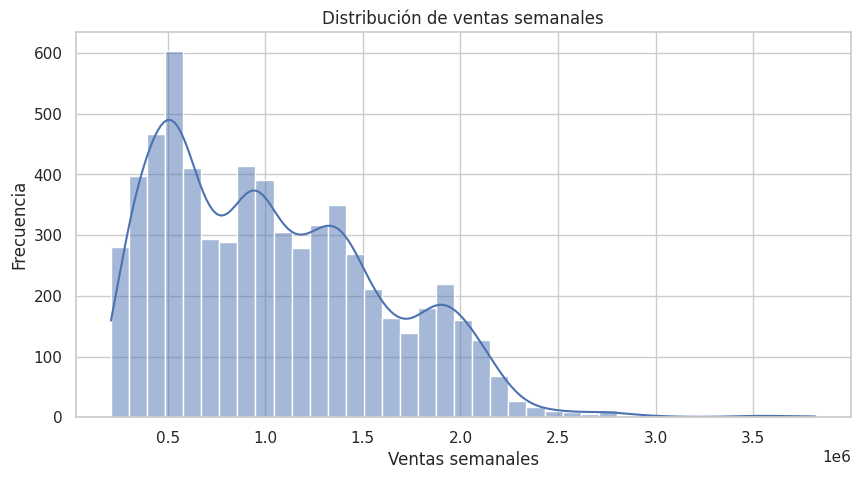

In [11]:
# Distribución de ventas semanales
plt.figure(figsize=(10, 5))
sns.histplot(df['Weekly_Sales'], kde=True)
plt.title('Distribución de ventas semanales')
plt.xlabel('Ventas semanales')
plt.ylabel('Frecuencia')
plt.show()

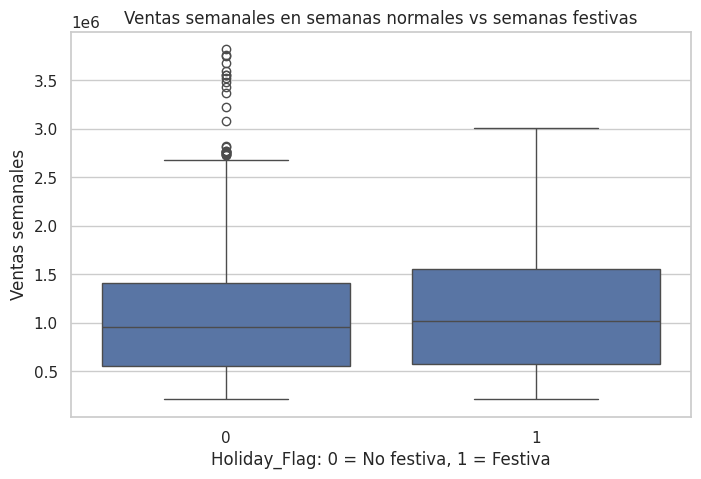

In [12]:
# Ventas en semanas normales vs festivas
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Holiday_Flag', y='Weekly_Sales')
plt.title('Ventas semanales en semanas normales vs semanas festivas')
plt.xlabel('Holiday_Flag: 0 = No festiva, 1 = Festiva')
plt.ylabel('Ventas semanales')
plt.show()

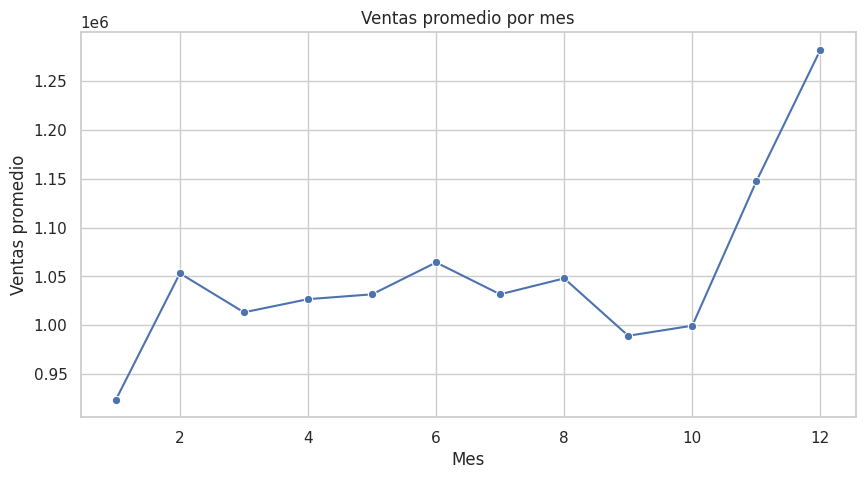

In [13]:
# Ventas promedio por mes
ventas_mes = df.groupby('Month', as_index=False)['Weekly_Sales'].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(data=ventas_mes, x='Month', y='Weekly_Sales', marker='o')
plt.title('Ventas promedio por mes')
plt.xlabel('Mes')
plt.ylabel('Ventas promedio')
plt.show()

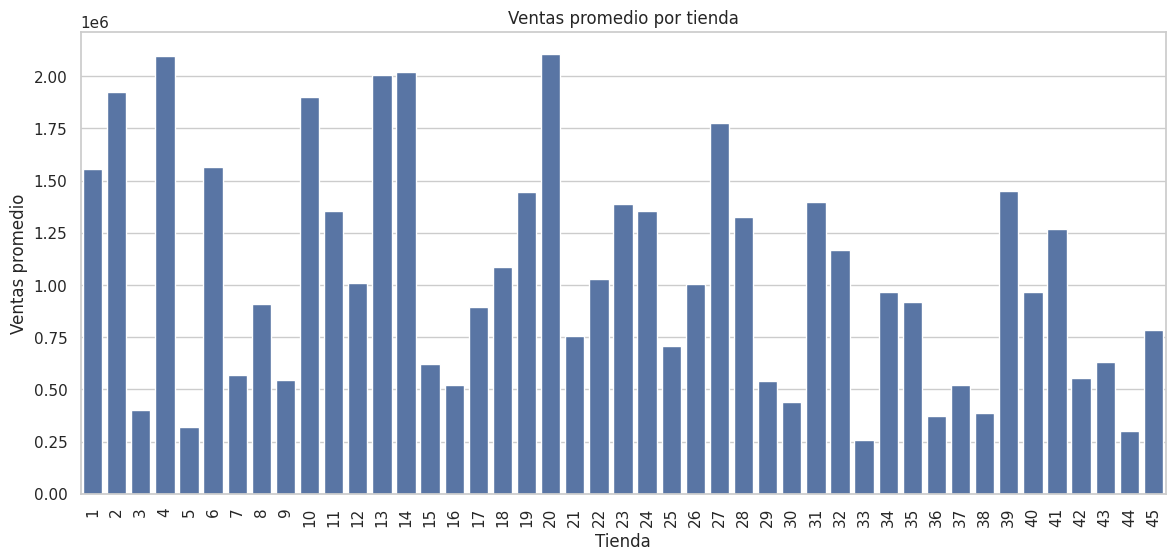

In [14]:
# Ventas promedio por tienda
ventas_tienda = df.groupby('Store', as_index=False)['Weekly_Sales'].mean().sort_values('Weekly_Sales', ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(data=ventas_tienda, x='Store', y='Weekly_Sales')
plt.title('Ventas promedio por tienda')
plt.xlabel('Tienda')
plt.ylabel('Ventas promedio')
plt.xticks(rotation=90)
plt.show()

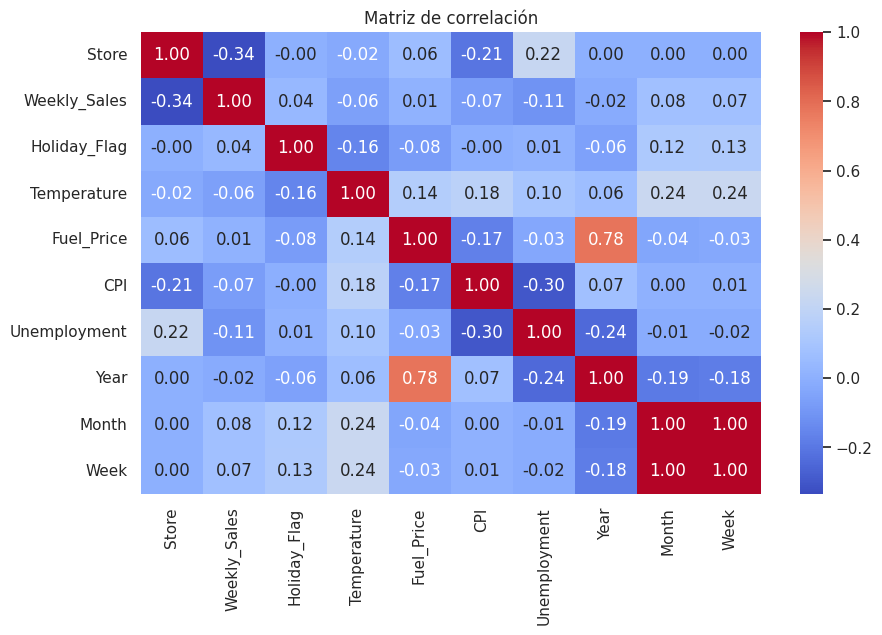

In [15]:
# Matriz de correlación
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

In [16]:
# Resumen comparativo por tipo de semana
resumen_holiday = df.groupby('Holiday_Flag')['Weekly_Sales'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
resumen_holiday

,count,mean,median,std,min,max
Holiday_Flag,,,,,,
0,5985,"1,041,256.38","956,211.20","558,957.44","209,986.25","3,818,686.45"
1,450,"1,122,887.89","1,018,538.04","627,684.93","215,359.21","3,004,702.33"


## 6. Definir el modelo, el método de trabajo y las métricas

Para cumplir con los objetivos del proyecto se aplican dos modelos vistos en analítica de negocios.

### Modelo 1: Pronóstico con Random Forest Regressor

Este modelo se utiliza para predecir la variable `Weekly_Sales`. Random Forest Regressor es un modelo supervisado basado en múltiples árboles de decisión. Se selecciona porque puede capturar relaciones no lineales entre ventas y variables como tienda, semana festiva, temperatura, precio del combustible, CPI, desempleo y temporada.

**Variable objetivo:** `Weekly_Sales`  
**Variables explicativas:** `Store`, `Holiday_Flag`, `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`, `Year`, `Month`, `Week`.

**Métricas:**

- **MAE:** error absoluto medio. Indica el error promedio en unidades monetarias.
- **RMSE:** raíz del error cuadrático medio. Penaliza más los errores grandes.
- **R²:** porcentaje de variabilidad de las ventas explicado por el modelo.

### Modelo 2: Agrupamiento con K-Means

Este modelo se utiliza para segmentar registros con características similares. K-Means agrupa observaciones de acuerdo con su cercanía en un espacio de variables numéricas. Antes de aplicar el modelo se realiza escalamiento, ya que las variables tienen diferentes magnitudes.

**Variables usadas para el agrupamiento:** `Weekly_Sales`, `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`, `Holiday_Flag`, `Month`.

**Métricas y validación:**

- **Método del codo:** ayuda a seleccionar un número razonable de clústeres.
- **Silhouette Score:** mide qué tan separados y cohesionados están los grupos.

## 7. Modelo de pronóstico: Random Forest Regressor

In [17]:
# Selección de variables para pronóstico
features_forecast = [
    'Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
    'CPI', 'Unemployment', 'Year', 'Month', 'Week'
]

target_forecast = 'Weekly_Sales'

X = df[features_forecast]
y = df[target_forecast]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Tamaño entrenamiento: {X_train.shape}")
print(f"Tamaño prueba: {X_test.shape}")

Tamaño entrenamiento: (5148, 9)
Tamaño prueba: (1287, 9)


In [18]:
# Entrenamiento del modelo Random Forest
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

In [19]:
# Evaluación del modelo de pronóstico
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²:   {r2:.4f}")

MAE:  $61,794.82
RMSE: $113,054.41
R²:   0.9603


In [20]:
# Comparación entre ventas reales y ventas predichas
resultados = pd.DataFrame({
    'Real': y_test.values,
    'Predicción': y_pred,
    'Error': y_test.values - y_pred
})

resultados.head(10)

,Real,Predicción,Error
0,"1,138,800.32","1,162,077.83","-23,277.51"
1,"1,304,850.67","1,420,515.42","-115,664.75"
2,"1,769,296.25","1,833,210.20","-63,913.95"
3,"1,077,640.13","962,996.91","114,643.22"
4,"428,851.99","430,976.21","-2,124.22"
5,"1,004,523.59","984,445.67","20,077.92"
6,"1,523,410.71","1,216,547.43","306,863.28"
7,"1,014,898.78","950,864.68","64,034.10"
8,"1,955,896.59","2,022,047.52","-66,150.93"
9,"958,667.23","960,302.44","-1,635.21"


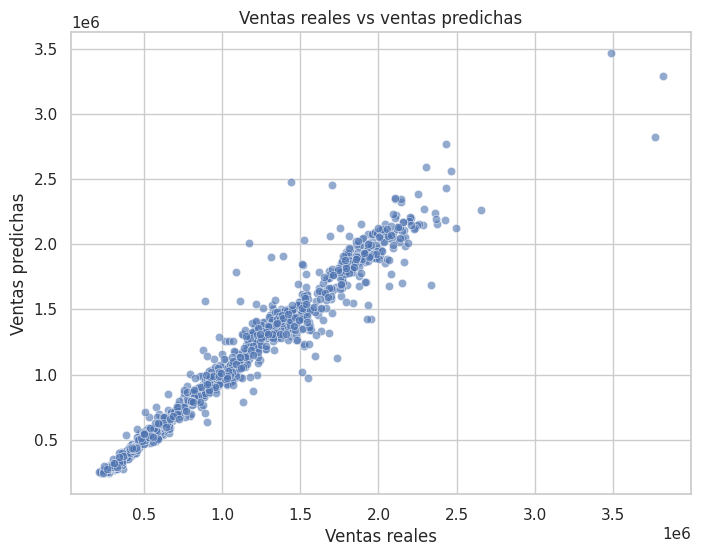

In [21]:
# Gráfico Real vs Predicho
plt.figure(figsize=(8, 6))
sns.scatterplot(x=resultados['Real'], y=resultados['Predicción'], alpha=0.6)
plt.title('Ventas reales vs ventas predichas')
plt.xlabel('Ventas reales')
plt.ylabel('Ventas predichas')
plt.show()

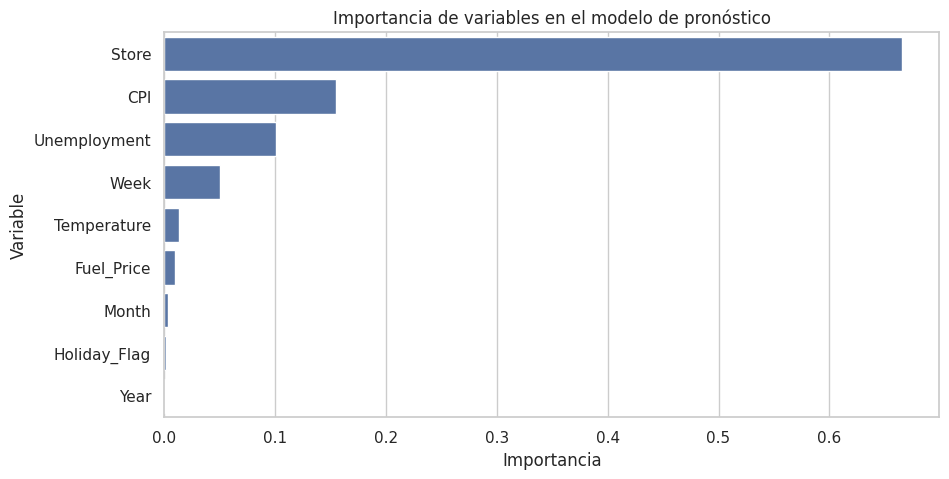

,Variable,Importancia
0,Store,0.67
4,CPI,0.16
5,Unemployment,0.10
8,Week,0.05
2,Temperature,0.01
3,Fuel_Price,0.01
7,Month,0.00
1,Holiday_Flag,0.00
6,Year,0.00


In [22]:
# Importancia de variables
importancias = pd.DataFrame({
    'Variable': features_forecast,
    'Importancia': rf_model.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importancias, x='Importancia', y='Variable')
plt.title('Importancia de variables en el modelo de pronóstico')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()

importancias

## 8. Modelo de agrupamiento: K-Means

El objetivo de este modelo es identificar grupos de registros con características similares. Para evitar que variables con valores grandes dominen el resultado, se aplica escalamiento con `StandardScaler`.

In [23]:
# Variables para agrupamiento
features_cluster = [
    'Weekly_Sales', 'Temperature', 'Fuel_Price',
    'CPI', 'Unemployment', 'Holiday_Flag', 'Month'
]

X_cluster = df[features_cluster].copy()

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

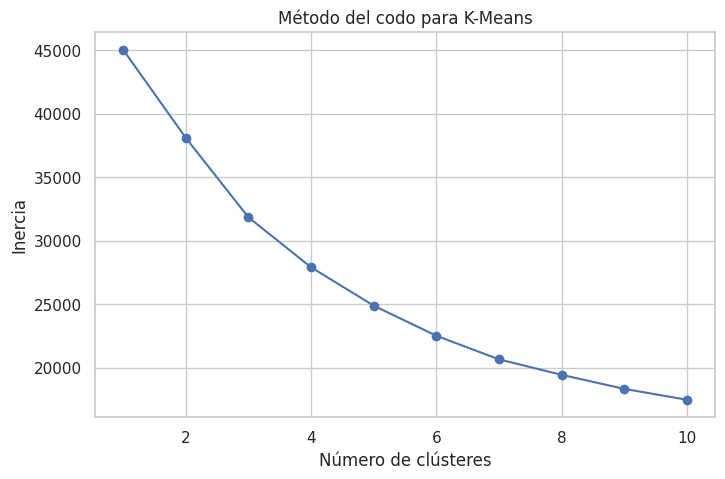

In [24]:
# Método del codo para seleccionar número de clústeres
inertias = []
ks = range(1, 11)

for k in ks:
    kmeans_temp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans_temp.fit(X_cluster_scaled)
    inertias.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(ks), inertias, marker='o')
plt.title('Método del codo para K-Means')
plt.xlabel('Número de clústeres')
plt.ylabel('Inercia')
plt.show()

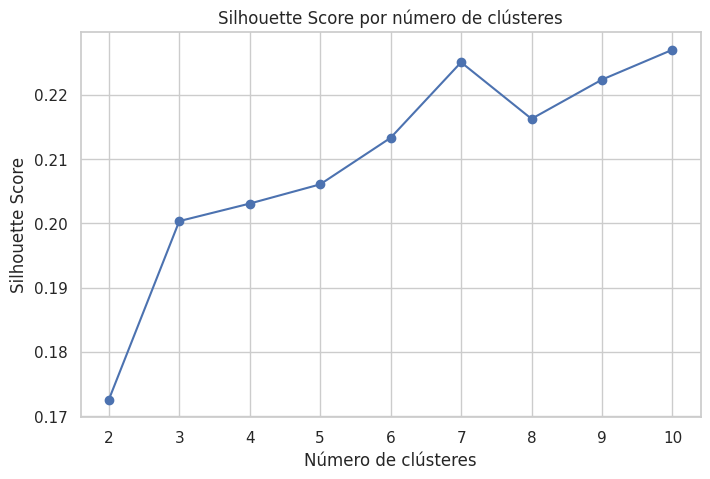

,k,Silhouette Score
0,2,0.17
1,3,0.20
2,4,0.20
3,5,0.21
4,6,0.21
5,7,0.23
6,8,0.22
7,9,0.22
8,10,0.23


In [25]:
# Evaluación con Silhouette Score para k entre 2 y 10
silhouette_scores = []
ks_silhouette = range(2, 11)

for k in ks_silhouette:
    kmeans_temp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, labels_temp)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(list(ks_silhouette), silhouette_scores, marker='o')
plt.title('Silhouette Score por número de clústeres')
plt.xlabel('Número de clústeres')
plt.ylabel('Silhouette Score')
plt.show()

pd.DataFrame({'k': list(ks_silhouette), 'Silhouette Score': silhouette_scores})

In [26]:
# Entrenamiento final de K-Means
# Se usa k=3 como punto de partida interpretable para segmentar niveles de comportamiento.
k_optimo = 3

kmeans = KMeans(n_clusters=k_optimo, random_state=RANDOM_STATE, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Perfil de los clústeres
perfil_clusters = df.groupby('Cluster')[features_cluster].mean().round(2)
perfil_clusters

,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,Holiday_Flag,Month
Cluster,,,,,,,
0,"1,095,531.37",58.87,3.48,133.64,8.46,0.00,6.32
1,"986,999.52",64.03,3.26,209.55,7.53,0.00,6.36
2,"1,122,887.89",50.23,3.23,171.27,8.07,1.00,7.90


In [27]:
# Cantidad de registros por clúster
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,2992
1,2993
2,450


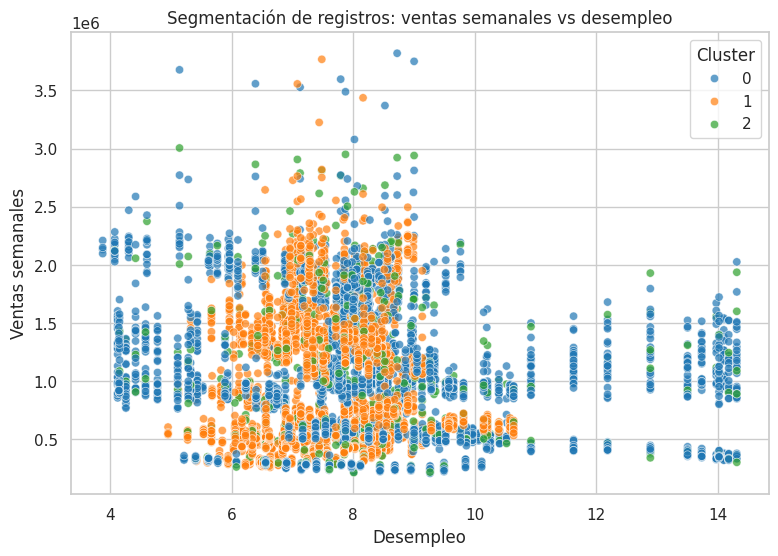

In [28]:
# Visualización de clústeres usando ventas y desempleo
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='Unemployment',
    y='Weekly_Sales',
    hue='Cluster',
    palette='tab10',
    alpha=0.7
)
plt.title('Segmentación de registros: ventas semanales vs desempleo')
plt.xlabel('Desempleo')
plt.ylabel('Ventas semanales')
plt.legend(title='Cluster')
plt.show()

## 9. Desplegar el modelo y validar resultados

En un contexto académico, el despliegue del modelo se realiza mediante una simulación de uso. Es decir, se toma un conjunto de datos de prueba, se generan predicciones y se comparan con los valores reales. En una organización real, este modelo podría integrarse a un tablero de control para estimar ventas por tienda y semana.

In [29]:
# Función simple para simular el uso del modelo con un nuevo registro

def predecir_ventas(store, holiday_flag, temperature, fuel_price, cpi, unemployment, year, month, week):
    nuevo_registro = pd.DataFrame({
        'Store': [store],
        'Holiday_Flag': [holiday_flag],
        'Temperature': [temperature],
        'Fuel_Price': [fuel_price],
        'CPI': [cpi],
        'Unemployment': [unemployment],
        'Year': [year],
        'Month': [month],
        'Week': [week]
    })
    prediccion = rf_model.predict(nuevo_registro)[0]
    return prediccion

# Ejemplo de predicción
venta_estimada = predecir_ventas(
    store=1,
    holiday_flag=0,
    temperature=60,
    fuel_price=3.5,
    cpi=220,
    unemployment=7.5,
    year=2012,
    month=11,
    week=45
)

print(f"Venta semanal estimada: ${venta_estimada:,.2f}")

Venta semanal estimada: $1,542,753.99


In [30]:
# Tabla resumida de resultados del modelo de pronóstico
metricas_modelo = pd.DataFrame({
    'Métrica': ['MAE', 'RMSE', 'R²'],
    'Valor': [mae, rmse, r2]
})

metricas_modelo

,Métrica,Valor
0,MAE,"61,794.82"
1,RMSE,"113,054.41"
2,R²,0.96


## 10. Discusión de los resultados

Los resultados obtenidos permiten analizar el comportamiento de las ventas semanales desde una perspectiva de negocio. El dataset utilizado contiene variables que representan tanto características internas de la operación, como la tienda y la semana festiva, como condiciones externas asociadas al entorno económico, entre ellas el precio del combustible, el índice de precios al consumidor y la tasa de desempleo. Esta combinación de variables es útil porque las ventas en retail no dependen únicamente de la tienda, sino también del contexto en el que se realizan las compras.

En primer lugar, el análisis exploratorio permite observar la distribución de `Weekly_Sales`. Esta variable es el centro del proyecto porque representa el nivel de ventas semanales que la empresa busca anticipar. La distribución puede mostrar diferencias importantes entre tiendas y semanas, lo cual confirma que no todas las observaciones se comportan de la misma forma. Para una organización de retail, esta variabilidad es clave, porque una tienda con ventas promedio altas requiere decisiones diferentes a una tienda con ventas promedio bajas. Por ejemplo, las tiendas con mayor volumen pueden necesitar mayor disponibilidad de inventario, más personal operativo, mayor coordinación logística y una planeación más cuidadosa de promociones.

La comparación entre semanas festivas y no festivas también es relevante. Las semanas festivas suelen estar asociadas con cambios en el comportamiento del consumidor. En algunos casos pueden generar aumentos de ventas por compras estacionales, promociones o mayor tráfico en tiendas. En otros casos pueden modificar la demanda de ciertos productos específicos. Por esta razón, incluir `Holiday_Flag` en el modelo es importante para capturar diferencias de comportamiento relacionadas con eventos especiales. Desde la perspectiva de negocio, esta variable puede ayudar a preparar estrategias comerciales anticipadas, como campañas promocionales, refuerzo de inventario o ajustes en los horarios de atención.

La creación de variables temporales como `Year`, `Month` y `Week` fortalece el análisis porque permite capturar patrones de temporada. En retail, la demanda no suele ser constante durante todo el año. Algunos meses pueden concentrar mayores ventas debido a celebraciones, vacaciones, cambios climáticos o ciclos de consumo. Al incluir estas variables en el modelo, se le proporciona información adicional para identificar patrones de comportamiento que no serían visibles si se usara únicamente la fecha original. Esta transformación es una parte fundamental del proceso de preparación de datos porque convierte una variable de tipo fecha en información útil para los modelos de machine learning.

El modelo de pronóstico con Random Forest Regressor permite estimar las ventas semanales a partir de las variables explicativas seleccionadas. Este modelo es adecuado porque puede capturar relaciones no lineales. En otras palabras, no asume que el efecto de una variable sobre las ventas sea siempre constante o lineal. Esto es importante en retail, donde la relación entre variables puede ser compleja. Por ejemplo, el impacto del desempleo sobre las ventas puede depender de la tienda, del mes o de si la semana es festiva. De igual forma, el precio del combustible puede afectar indirectamente el comportamiento de compra al modificar costos de transporte o disponibilidad de ingreso de los consumidores.

Las métricas MAE, RMSE y R² permiten evaluar el desempeño del modelo desde diferentes ángulos. El MAE muestra el error promedio de predicción en las mismas unidades de la variable objetivo, lo cual facilita su interpretación gerencial. El RMSE también mide error, pero penaliza con mayor fuerza los errores grandes. Esto es útil porque en planeación de ventas los errores extremos pueden ser más costosos que errores pequeños. El R² indica qué proporción de la variabilidad de las ventas logra explicar el modelo. Si el R² es alto, se puede interpretar que las variables seleccionadas tienen buena capacidad para explicar el comportamiento de las ventas. Si el R² es bajo, sería necesario incorporar nuevas variables, probar otros modelos o revisar la calidad de los datos.

El gráfico de ventas reales frente a ventas predichas permite validar visualmente el comportamiento del modelo. Cuando las predicciones se acercan a los valores reales, los puntos tienden a alinearse alrededor de una diagonal imaginaria. Si existe una dispersión amplia, significa que el modelo presenta dificultades para predecir ciertos registros. Este análisis visual complementa las métricas numéricas y permite identificar si el modelo funciona bien de manera general o si falla en casos específicos, como tiendas de ventas muy altas o semanas atípicas.

La importancia de variables permite identificar cuáles factores tienen mayor peso en la predicción. Esta información es especialmente valiosa para la toma de decisiones porque no solo interesa predecir, sino también comprender. Si `Store` aparece como una variable muy importante, significa que el comportamiento individual de cada tienda explica una parte considerable de las ventas. Esto tendría sentido porque cada tienda puede estar ubicada en mercados diferentes, con públicos, tamaños y patrones de consumo distintos. Si variables como `Month` o `Week` tienen alta importancia, se confirma que la temporada influye en el comportamiento de la demanda. Si variables económicas como `CPI`, `Fuel_Price` o `Unemployment` tienen peso relevante, el negocio debería monitorear el entorno económico al momento de planear ventas e inventarios.

El modelo de agrupamiento con K-Means aporta una segunda perspectiva. Mientras el modelo de pronóstico busca estimar un valor numérico, el agrupamiento busca encontrar segmentos de registros con características similares. Esta técnica es útil porque permite pasar de una visión general del dataset a una visión segmentada. Los clústeres pueden representar grupos de semanas o tiendas con niveles de ventas, condiciones económicas o comportamientos similares. Por ejemplo, un clúster podría agrupar registros con ventas altas y desempleo bajo, mientras otro podría concentrar ventas menores en contextos económicos menos favorables. Esta segmentación puede apoyar decisiones diferenciadas en lugar de aplicar una misma estrategia para todas las tiendas.

El método del codo y el Silhouette Score ayudan a justificar el número de clústeres. Esto es importante porque K-Means requiere definir previamente cuántos grupos se desean construir. Si se elige un número de clústeres sin justificación, la segmentación puede ser arbitraria. El método del codo permite observar en qué punto agregar más clústeres deja de reducir la inercia de manera significativa. El Silhouette Score, por su parte, evalúa qué tan bien separados están los grupos. En un proyecto académico y empresarial, esta justificación fortalece la validez del análisis y evita que el agrupamiento sea presentado como una decisión subjetiva.

Desde una perspectiva práctica, los resultados del agrupamiento pueden traducirse en estrategias diferenciadas. Los grupos con ventas altas podrían ser priorizados para mantener disponibilidad de productos, reforzar logística y evaluar campañas de fidelización. Los grupos con ventas medias podrían recibir acciones comerciales para aumentar su desempeño. Los grupos con ventas bajas podrían analizarse con mayor detalle para identificar problemas de ubicación, demanda, inventario o condiciones económicas. Sin embargo, es importante aclarar que el modelo no reemplaza el criterio gerencial. Sus resultados deben ser interpretados junto con conocimiento del negocio, información de clientes, estrategia comercial y restricciones operativas.

En conjunto, el análisis demuestra que la analítica de negocios puede transformar datos históricos en herramientas de apoyo para la toma de decisiones. El modelo de pronóstico permite anticipar ventas y reducir incertidumbre en la planeación. El modelo de agrupamiento permite identificar segmentos con comportamientos similares y diseñar estrategias más específicas. Aunque el proyecto no garantiza por sí solo una reducción inmediata de costos o un aumento automático de ingresos, sí proporciona una base analítica para tomar mejores decisiones. Para implementar este tipo de solución en una organización real, sería necesario actualizar el modelo periódicamente, validar sus predicciones con datos nuevos, incorporar variables adicionales y conectarlo con procesos internos como compras, abastecimiento, promociones y planeación financiera.

## 11. Consideraciones éticas y prácticas

El uso de modelos analíticos en retail debe realizarse con responsabilidad. Aunque este dataset no contiene información personal de clientes, sus resultados pueden influir en decisiones operativas que afectan a trabajadores, proveedores y consumidores. Por ejemplo, si un modelo predice baja demanda en una tienda, la organización podría reducir inventario o personal. Por esta razón, las predicciones no deben tomarse como verdades absolutas, sino como insumos para la toma de decisiones.

También es importante reconocer que los modelos pueden reflejar limitaciones de los datos históricos. Si los datos contienen periodos atípicos, cambios económicos fuertes o condiciones particulares de algunas tiendas, el modelo podría aprender patrones que no necesariamente se repiten en el futuro. Por ello, se recomienda monitorear el desempeño del modelo y actualizarlo con datos recientes.

Desde una perspectiva práctica, el modelo debe integrarse a procesos reales de negocio. No basta con construir una predicción; es necesario definir quién usará el resultado, con qué frecuencia, bajo qué criterios y cómo se evaluará su impacto. Además, las decisiones basadas en datos deben combinarse con conocimiento humano, experiencia del mercado y análisis de contexto.

## 12. Conclusiones

El proyecto permitió aplicar técnicas de analítica de negocios a un problema realista del sector retail. A partir del dataset de ventas de Walmart se construyó un flujo de trabajo completo que incluyó carga de datos, revisión de calidad, transformación de fechas, análisis exploratorio, construcción de modelos y discusión de resultados.

La variable `Weekly_Sales` fue seleccionada como variable numérica de pronóstico, ya que representa directamente las ventas semanales. El modelo Random Forest Regressor permitió estimar esta variable usando información de tienda, semana festiva, condiciones económicas y variables temporales. Las métricas MAE, RMSE y R² permitieron evaluar el desempeño del modelo y entender su utilidad para la planeación.

El modelo K-Means permitió segmentar registros con características similares. Esta segmentación ayuda a diferenciar comportamientos entre grupos de semanas o tiendas, lo cual puede apoyar decisiones comerciales y operativas más específicas.

En conclusión, la analítica de negocios ofrece herramientas valiosas para reducir incertidumbre, anticipar demanda y mejorar la toma de decisiones en organizaciones de retail.

## 13. Recomendaciones

1. Utilizar el modelo de pronóstico como apoyo para la planeación de inventarios por tienda y semana.
2. Analizar de forma separada las semanas festivas, ya que pueden presentar comportamientos diferentes frente a semanas normales.
3. Usar los clústeres para diseñar estrategias diferenciadas según el nivel de ventas y las condiciones económicas de cada grupo.
4. Actualizar el modelo periódicamente con datos recientes para mantener su capacidad predictiva.
5. Incorporar nuevas variables si están disponibles, como promociones, categorías de producto, tráfico de clientes, ubicación de tiendas o campañas comerciales.
6. Complementar los resultados del modelo con criterio gerencial y conocimiento del negocio.
7. Implementar tableros de control que permitan visualizar predicciones, errores y segmentos de manera sencilla para los tomadores de decisiones.

## 14. Bibliografía

- Kaggle. *Walmart Sales Dataset*. Plataforma Kaggle.
- Scikit-learn. Documentación oficial de modelos Random Forest, K-Means y métricas de evaluación.
- Pandas. Documentación oficial para manipulación y análisis de datos.
- Matplotlib y Seaborn. Documentación oficial para visualización de datos.
- Material del curso de Analítica de Negocios.